In [1]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# %%
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# -------------------

In [ ]:
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent  # notebook in output/ → repo root
DATA_DIR = REPO_ROOT / "nito" / "Data"

loads_all = np.load(DATA_DIR / "loads.npy", allow_pickle=True)
bcs_all = np.load(DATA_DIR / "boundary_conditions.npy", allow_pickle=True)
shapes_all = np.load(DATA_DIR / "shapes.npy", allow_pickle=True)
topo_all = np.load(DATA_DIR / "topologies.npy", allow_pickle=True)
ID_IDX = 10

In [3]:
dims = shapes_all[ID_IDX]

loads = loads_all[ID_IDX, :, 0:3] * np.array([[1,1,1]]) * np.max(dims)
load_v = loads_all[ID_IDX, :, 3:]

bcs = bcs_all[ID_IDX] [:, 0:3]* np.array([[1,1,1]]) * np.max(dims)
bc_c = bcs_all[ID_IDX] [:, 3:]

xPhys = topo_all[ID_IDX].reshape(dims)


In [4]:
loads_all[ID_IDX, :, 0:3]

array([[0.0, 0.140625, 0.1875]], dtype=object)

I0000 00:00:1771445021.130325   61528 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1771445021.156815   61528 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1771445021.978764   61528 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


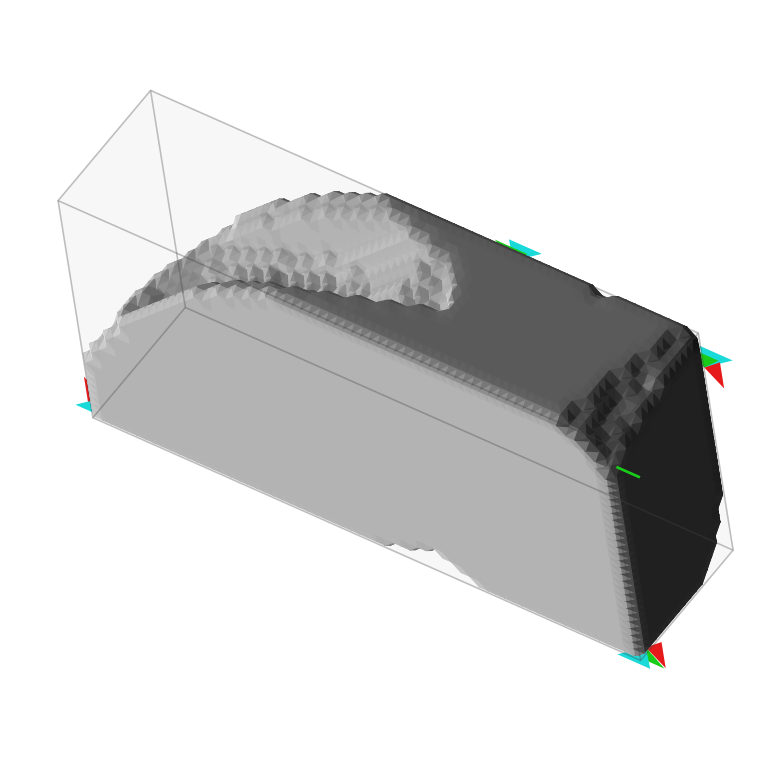

In [5]:
# %%
# Combined final plot:
# - Marching-cubes mesh from rho_ss (shape [nely*SS, nelx*SS, nelz*SS] = [y,x,z])
# - Overlay loads (green cone arrows) + fixed BC triangles (x=red, y=green, z=cyan)
# - CAD screen convention: x→right, y→up, z→out of page (toward you)
# - Curvature coloring is a toggle (requires gcurv + batch_func defined earlier)

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.colors import LightSource
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import ipywidgets as widgets
from IPython.display import display


def _cad_to_mpl_points(P_cad, dims_xyz):
    P = np.asarray(P_cad, float).copy()
    P[..., 2] = dims_xyz[2] - P[..., 2]
    return P

def _cad_to_mpl_dirs(V_cad):
    V = np.asarray(V_cad, float).copy()
    V[..., 2] = -V[..., 2]
    return V

def _normalize(v, eps=1e-12):
    n = np.linalg.norm(v)
    return v * 0.0 if n < eps else v / n

def _orthonormal_basis(w):
    w = _normalize(w)
    if np.linalg.norm(w) < 1e-12:
        return np.array([1.0,0.0,0.0]), np.array([0.0,1.0,0.0])
    a = np.array([0.0,0.0,1.0]) if abs(w[2]) < 0.9 else np.array([0.0,1.0,0.0])
    u = _normalize(np.cross(w, a))
    v = np.cross(w, u)
    return u, v

def add_cone_arrow(ax, start, direction, length,
                   color=(0.1, 0.8, 0.1, 1.0),
                   cone_frac=0.45, radius_frac=0.16,
                   n_sides=24, lw=1.2, zorder=50):
    start = np.asarray(start, float)
    d = np.asarray(direction, float)
    if np.linalg.norm(d) < 1e-12:
        return
    w = _normalize(d)
    L = float(length)
    tip = start + w * L

    h = L * float(cone_frac)
    r = L * float(radius_frac)
    base_center = tip - w * h

    ax.plot([start[0], base_center[0]],
            [start[1], base_center[1]],
            [start[2], base_center[2]],
            color=color, lw=lw, zorder=zorder)

    u, v = _orthonormal_basis(w)
    thetas = np.linspace(0, 2*np.pi, n_sides, endpoint=False)
    circle = np.array([base_center + r*(np.cos(t)*u + np.sin(t)*v) for t in thetas])

    tris = [[tip, circle[i], circle[(i+1) % n_sides]] for i in range(n_sides)]
    poly = Poly3DCollection(tris, facecolors=color, edgecolors=color, linewidths=0.0, zorder=zorder)
    ax.add_collection3d(poly)

def add_bc_triangle_head(ax, tip, axis_dir, head_len, head_width,
                         color=(0.9, 0.1, 0.1, 1.0),
                         zorder=60):
    # "less pointy": use relatively large head_width/head_len
    tip = np.asarray(tip, float)
    w = _normalize(np.asarray(axis_dir, float))
    if np.linalg.norm(w) < 1e-12:
        return

    base_center = tip - w * float(head_len)
    u, _ = _orthonormal_basis(w)

    left  = base_center - u * float(head_width)
    right = base_center + u * float(head_width)

    tri = [tip, left, right]
    poly = Poly3DCollection([tri], facecolors=color, edgecolors=color, linewidths=0.0, zorder=zorder)
    ax.add_collection3d(poly)

def add_transparent_bbox(ax, dims_xyz, face_alpha=0.05, edge_alpha=0.18, lw=0.7):
    nelx, nely, nelz = map(float, dims_xyz.tolist())
    C = np.array([
        [0,    0,    0],
        [nelx, 0,    0],
        [nelx, nely, 0],
        [0,    nely, 0],
        [0,    0,    nelz],
        [nelx, 0,    nelz],
        [nelx, nely, nelz],
        [0,    nely, nelz],
    ], dtype=float)

    faces = [
        [C[0], C[1], C[2], C[3]],
        [C[4], C[5], C[6], C[7]],
        [C[0], C[1], C[5], C[4]],
        [C[3], C[2], C[6], C[7]],
        [C[0], C[3], C[7], C[4]],
        [C[1], C[2], C[6], C[5]],
    ]
    poly = Poly3DCollection(
        faces,
        facecolors=(0.7, 0.7, 0.7, face_alpha),
        edgecolors=(0.25, 0.25, 0.25, edge_alpha),
        linewidths=lw,
        zorder=0
    )
    ax.add_collection3d(poly)


def build_topology_mesh_and_colors(
    rho_ss_yxz: np.ndarray,
    dims_xyz: np.ndarray
):
    rho = np.asarray(rho_ss_yxz, float)
    rho = rho[:, :, ::-1]
    nely1,nelx1,nelz1 = rho.shape
    nelm1 = max(nely1,nelx1,nelz1)
    nelx, nely, nelz = map(float, dims_xyz.tolist())

    # pad (prevents open surfaces at boundary and matches your existing style)
    pad = np.zeros((nely1 + 2, nelx1 + 2, nelz1 + 2), dtype=float)
    pad[1:-1, 1:-1, 1:-1] = rho

    verts, faces, normals, values = measure.marching_cubes(pad,level = 0.3,step_size=1,allow_degenerate=False,gradient_direction='ascent') #set the density cutoff
    ls = LightSource(-112,24)

    f_norm =  -np.array([np.array((np.sum(normals[face[:], 0]/3), np.sum(normals[face[:], 1]/3), np.sum(normals[face[:], 2]/3))/np.sqrt(np.sum(normals[face[:], 0]/3)**2 + np.sum(normals[face[:], 1]/3)**2 + np.sum(normals[face[:], 2]/3)**2)) for face in faces])
    cl = ls.shade_normals(f_norm,fraction=1.0)
    shade_mapper = cm.ScalarMappable(norm=colors.Normalize(vmin=0.0, vmax=1.0, clip=True), cmap=cm.gray)
    shade = shade_mapper.to_rgba(cl).reshape([-1,4])
    vertices= np.take(verts, faces,axis = 0) #/nelx1 * (np.array([[nelm1/nely1, nelm1/nelm1, nelm1/nelz1]]))
    #shade[:, 3] = mesh_alpha



    return vertices, shade




tri_verts, fc_shade= build_topology_mesh_and_colors(
    rho_ss_yxz=xPhys,
    dims_xyz=np.asarray(dims, float)
)

# Prep BCs in mpl coordinates (CAD->mpl reflect z)
dims_xyz = np.asarray(dims, float)
loads_mpl  = _cad_to_mpl_points(loads, dims_xyz)
loadv_mpl  = _cad_to_mpl_dirs(load_v)
bcs_mpl    = _cad_to_mpl_points(bcs, dims_xyz)

# Color mapping for constrained axis
BC_AXIS_COLORS = {
    0: (0.90, 0.10, 0.10, 1.0),  # x -> red
    1: (0.10, 0.80, 0.10, 1.0),  # y -> green
    2: (0.10, 0.85, 0.85, 1.0),  # z -> cyan
}

# Figure / axes
fig = plt.figure(figsize=(6, 6), dpi=160)
ax = fig.add_subplot(1, 1, 1, projection="3d")
ax.set_proj_type("ortho")

nelx, nely, nelz = dims_xyz
ax.set_xlim(0, nelx)
ax.set_ylim(0, nely)
ax.set_zlim(0, nelz)
ax.set_box_aspect((nelx, nely, nelz))

# CAD screen convention (x right, y up, z out of page) using our z-reflection mapping
ax.view_init(elev=-30, azim=120,roll=-40)
ax.invert_yaxis()
ax.set_axis_off()

add_transparent_bbox(ax, dims_xyz)

# Topology mesh (transparent)
mesh_poly = Poly3DCollection(tri_verts, zorder=5)
mesh_poly.set_facecolor(fc_shade)

mesh_poly.set_edgecolor(fc_shade )
ax.add_collection3d(mesh_poly)

# Overlay: loads (cone arrows)
arrow_len = 0.28 * float(min(dims_xyz))
for p, v in zip(loads_mpl, loadv_mpl):
    add_cone_arrow(ax, start=p, direction=v, length=arrow_len)

# Overlay: fixed BC triangle heads (one per constrained axis)
bc_head_len = 0.13 * float(min(dims_xyz))
bc_head_w   = 0.12 * float(min(dims_xyz))  # wide => less pointy

for p_cad, c in zip(bcs, bc_c):
    for k in range(3):
        if abs(c[k]) > 1e-12:
            # inward direction in CAD frame along axis k
            sign_cad = +1.0 if p_cad[k] <= 0.5 * dims_xyz[k] else -1.0
            d_cad = np.zeros(3, float); d_cad[k] = sign_cad

            p_mpl = _cad_to_mpl_points(p_cad, dims_xyz)
            d_mpl = _cad_to_mpl_dirs(d_cad)

            add_bc_triangle_head(
                ax,
                tip=p_mpl,
                axis_dir=d_mpl,
                head_len=bc_head_len,
                head_width=bc_head_w,
                color=BC_AXIS_COLORS[k],
            )

plt.show()


